# Balance Demographic — Clean Training Dataset

This notebook loads the clean training dataset (`clean_train_dataset.csv`) for further analysis or processing.

In [1]:
# Load the clean training dataset
import pandas as pd

df = pd.read_csv('clean_train_dataset.csv')
print('Clean training dataset loaded. Shape:', df.shape)
df.head()

Clean training dataset loaded. Shape: (81474, 39)


,number_inpatient,time_in_hospital,number_emergency,number_outpatient,num_medications,num_lab_procedures,diabetesMed,insulin,metformin,admission_type_id,...,diag_1_Respiratory,diag_2_Circulatory,diag_2_Diabetes,diag_2_Digestive,diag_2_Genitourinary,diag_2_Injury,diag_2_Musculoskeletal,diag_2_Neoplasms,diag_2_Other,diag_2_Respiratory
0,0,1,0,0,1,41,0,0,0,6,...,0,0,0,0,0,0,0,0,1,0
1,0,3,0,0,18,59,1,3,0,1,...,0,0,1,0,0,0,0,0,0,0
2,1,2,0,2,13,11,1,0,0,1,...,0,0,1,0,0,0,0,0,0,0
3,0,2,0,0,16,44,1,3,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,3,0,0,16,31,1,2,0,2,...,0,1,0,0,0,0,0,0,0,0


## Demographic Distributions: Age, Gender, Race

Display the counts and visualizations for age, gender, and race in the clean training dataset.

### Demographic Group Label Reference

- **Age Groups:**
    - 0: [0-10)
    - 1: [10-20)
    - 2: [20-30)
    - 3: [30-40)
    - 4: [40-50)
    - 5: [50-60)
    - 6: [60-70)
    - 7: [70-80)
    - 8: [80-90)
    - 9: [90-100)
- **Gender:**
    - 0: Female
    - 1: Male
- **Race:**
    - race_AfricanAmerican: African American
    - race_Asian: Asian
    - race_Caucasian: Caucasian
    - race_Hispanic: Hispanic
    - race_Other: Other

**Note:** These labels correspond to the group codes shown in the demographic distributions above.

Age distribution:
age
0      133
1      570
2     1330
3     3013
4     7782
5    13847
6    17858
7    21004
8    13718
9     2219
Name: count, dtype: int64

Gender distribution:
gender
0    43880
1    37594
Name: count, dtype: int64

Race distribution:
race_AfricanAmerican: 15516
race_Asian: 526
race_Caucasian: 60773
race_Hispanic: 1643
race_Other: 1221


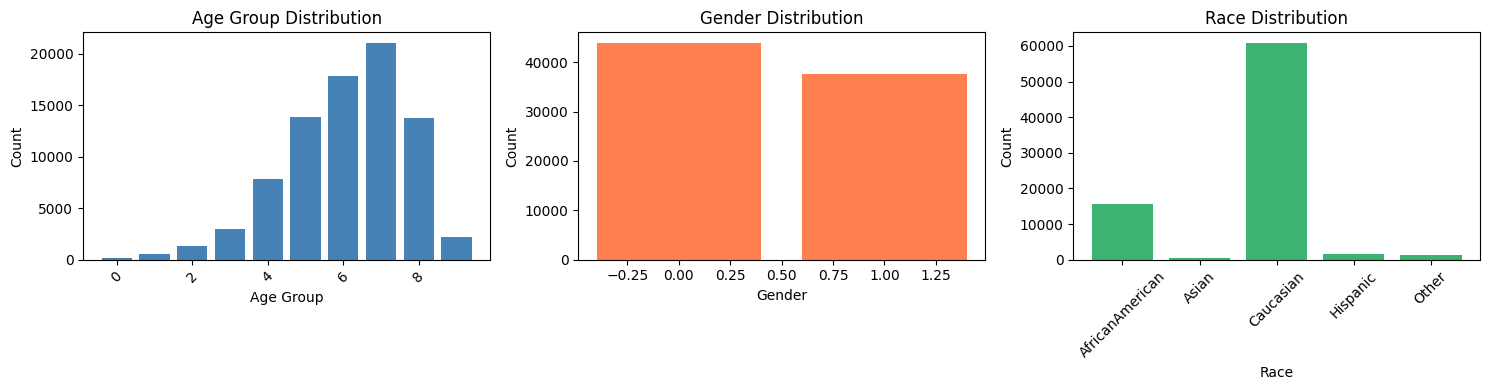

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify demographic columns
demographic_info = {}
age_col = 'age' if 'age' in df.columns else None
gender_col = 'gender' if 'gender' in df.columns else None
race_cols = [c for c in df.columns if c.startswith('race_')] if any(c.startswith('race_') for c in df.columns) else []

demographic_info['age'] = age_col
demographic_info['gender'] = gender_col
demographic_info['race'] = race_cols

# Print counts
def print_counts():
    if age_col:
        print('Age distribution:')
        print(df[age_col].value_counts().sort_index())
    if gender_col:
        print('\nGender distribution:')
        print(df[gender_col].value_counts())
    if race_cols:
        print('\nRace distribution:')
        for race_col in race_cols:
            print(f"{race_col}: {df[race_col].sum()}")

print_counts()

# Visualize
def plot_demographics():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # Age
    if age_col:
        age_counts = df[age_col].value_counts().sort_index()
        axes[0].bar(age_counts.index, age_counts.values, color='steelblue')
        axes[0].set_title('Age Group Distribution')
        axes[0].set_xlabel('Age Group')
        axes[0].set_ylabel('Count')
        axes[0].tick_params(axis='x', rotation=45)
    # Gender
    if gender_col:
        gender_counts = df[gender_col].value_counts()
        axes[1].bar(gender_counts.index, gender_counts.values, color='coral')
        axes[1].set_title('Gender Distribution')
        axes[1].set_xlabel('Gender')
        axes[1].set_ylabel('Count')
    # Race
    if race_cols:
        race_counts = {col.replace('race_', ''): df[col].sum() for col in race_cols}
        axes[2].bar(race_counts.keys(), race_counts.values(), color='mediumseagreen')
        axes[2].set_title('Race Distribution')
        axes[2].set_xlabel('Race')
        axes[2].set_ylabel('Count')
        axes[2].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

plot_demographics()

## Soft Demographic Balancing (Age, Race, Gender)

This section applies soft balancing to the race, age, and gender groups, reducing extreme imbalance while keeping the dataset size large and realistic. The target variable (`readmitted`) is NOT balanced.

Original race group sizes:
race_AfricanAmerican: 15516
race_Asian: 526
race_Caucasian: 60773
race_Hispanic: 1643
race_Other: 1221

Total dataset size before: 81474
Total dataset size after: 33390

New race group sizes:
race_AfricanAmerican: 15000
race_Asian: 526
race_Caucasian: 15000
race_Hispanic: 1643
race_Other: 1221


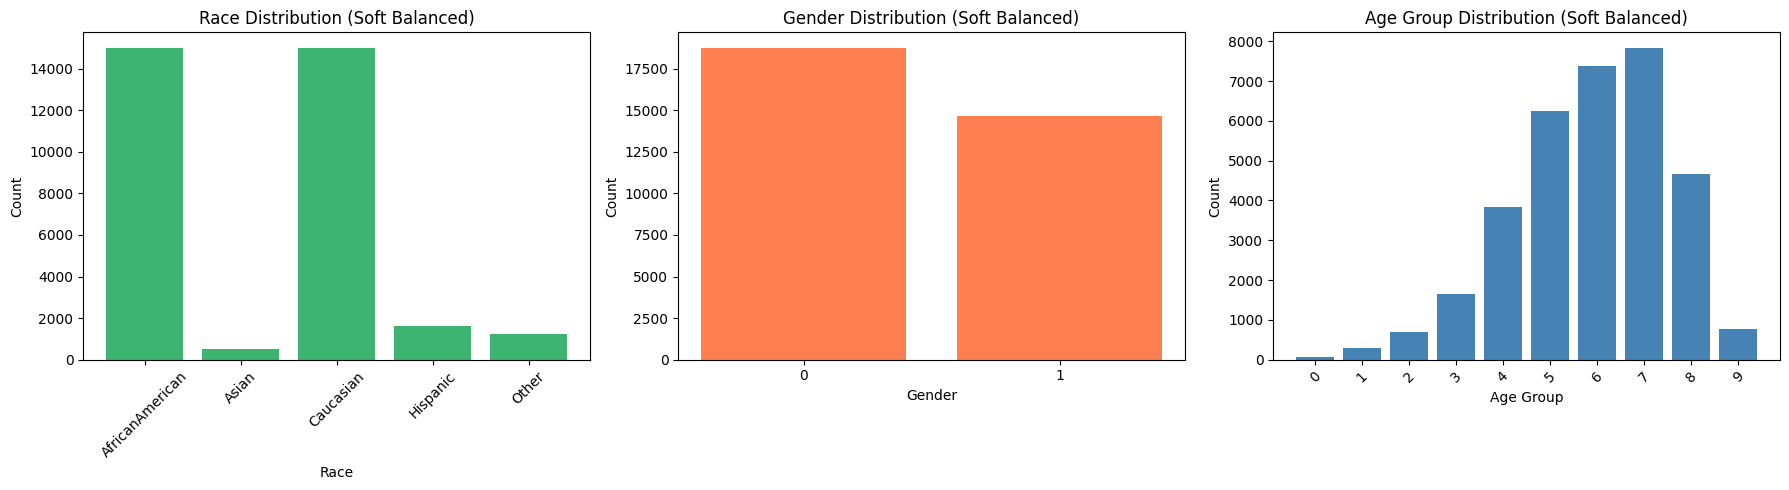

In [4]:
# --- Soft Balancing by Race ---

import numpy as np

race_cols = [c for c in df.columns if c.startswith('race_')]

race_cap = 15000

random_state = 42



# Find group sizes

race_sizes = {col: df[col].sum() for col in race_cols}

print('Original race group sizes:')

for k, v in race_sizes.items():
    print(f'{k}: {v}')



# Build mask for rows to keep

keep_idx = []

for col in race_cols:

    idx = df[df[col] == 1].index

    if len(idx) > race_cap:

        idx = np.random.RandomState(random_state).choice(idx, race_cap, replace=False)

    keep_idx.extend(idx)



df_soft = df.loc[keep_idx].copy()



print(f'\nTotal dataset size before: {len(df)}')

print(f'Total dataset size after: {len(df_soft)}')



# Print new race distribution

print('\nNew race group sizes:')

for col in race_cols:
    print(f'{col}:', df_soft[col].sum())



# --- Plot updated distributions ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Race

race_counts = {col.replace('race_', ''): df_soft[col].sum() for col in race_cols}

axes[0].bar(race_counts.keys(), race_counts.values(), color='mediumseagreen')

axes[0].set_title('Race Distribution (Soft Balanced)')

axes[0].set_xlabel('Race')

axes[0].set_ylabel('Count')

axes[0].tick_params(axis='x', rotation=45)

# Gender

if 'gender' in df_soft.columns:

    gender_counts = df_soft['gender'].value_counts()

    axes[1].bar(gender_counts.index.astype(str), gender_counts.values, color='coral')

    axes[1].set_title('Gender Distribution (Soft Balanced)')

    axes[1].set_xlabel('Gender')

    axes[1].set_ylabel('Count')

# Age

if 'age' in df_soft.columns:

    age_counts = df_soft['age'].value_counts().sort_index()

    axes[2].bar(age_counts.index.astype(str), age_counts.values, color='steelblue')

    axes[2].set_title('Age Group Distribution (Soft Balanced)')

    axes[2].set_xlabel('Age Group')

    axes[2].set_ylabel('Count')

    axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()


Original age group sizes (after race balancing):
age
0      55
1     283
2     699
3    1653
4    3840
5    6237
6    7365
7    7831
8    4657
9     770
Name: count, dtype: int64

Total dataset size after age balancing: 33390
New age group sizes:
age
0      55
1     283
2     699
3    1653
4    3840
5    6237
6    7365
7    7831
8    4657
9     770
Name: count, dtype: int64

Original gender group sizes (after age balancing):
gender
0    18740
1    14650
Name: count, dtype: int64

Total dataset size after gender balancing: 33390
New gender group sizes:
gender
0    18740
1    14650
Name: count, dtype: int64


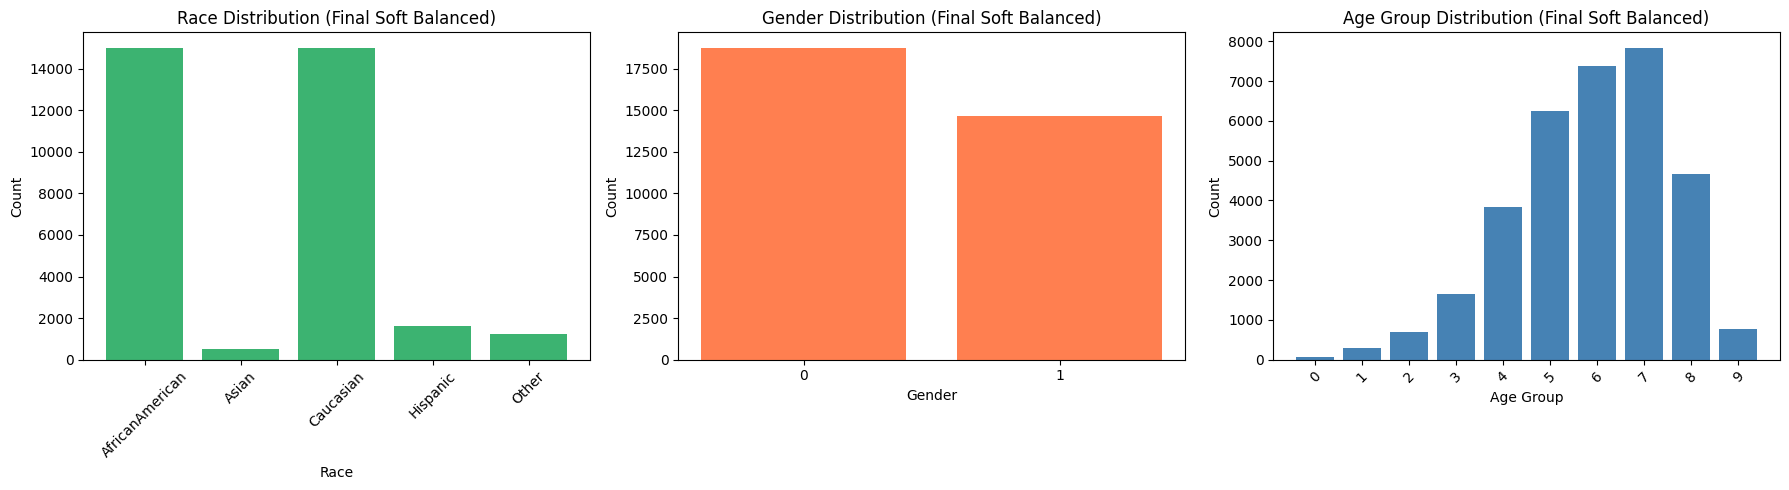

In [5]:
# --- Soft Balancing by Age ---
age_cap = 8000  # Set a reasonable cap for age groups
age_col = 'age'
if age_col in df_soft.columns:
    age_sizes = df_soft[age_col].value_counts().sort_index()
    print('\nOriginal age group sizes (after race balancing):')
    print(age_sizes)
    keep_idx_age = []
    for age_group, size in age_sizes.items():
        idx = df_soft[df_soft[age_col] == age_group].index
        if size > age_cap:
            idx = np.random.RandomState(random_state).choice(idx, age_cap, replace=False)
        keep_idx_age.extend(idx)
    df_soft = df_soft.loc[keep_idx_age].copy()
    print(f'\nTotal dataset size after age balancing: {len(df_soft)}')
    print('New age group sizes:')
    print(df_soft[age_col].value_counts().sort_index())

# --- Soft Balancing by Gender ---
gender_cap = 20000  # Set a reasonable cap for gender groups
gender_col = 'gender'
if gender_col in df_soft.columns:
    gender_sizes = df_soft[gender_col].value_counts()
    print('\nOriginal gender group sizes (after age balancing):')
    print(gender_sizes)
    keep_idx_gender = []
    for gender_group, size in gender_sizes.items():
        idx = df_soft[df_soft[gender_col] == gender_group].index
        if size > gender_cap:
            idx = np.random.RandomState(random_state).choice(idx, gender_cap, replace=False)
        keep_idx_gender.extend(idx)
    df_soft = df_soft.loc[keep_idx_gender].copy()
    print(f'\nTotal dataset size after gender balancing: {len(df_soft)}')
    print('New gender group sizes:')
    print(df_soft[gender_col].value_counts())

# --- Plot updated distributions after all balancing ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Race
race_counts = {col.replace('race_', ''): df_soft[col].sum() for col in race_cols}
axes[0].bar(race_counts.keys(), race_counts.values(), color='mediumseagreen')
axes[0].set_title('Race Distribution (Final Soft Balanced)')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
# Gender
if gender_col in df_soft.columns:
    gender_counts = df_soft[gender_col].value_counts()
    axes[1].bar(gender_counts.index.astype(str), gender_counts.values, color='coral')
    axes[1].set_title('Gender Distribution (Final Soft Balanced)')
    axes[1].set_xlabel('Gender')
    axes[1].set_ylabel('Count')
# Age
if age_col in df_soft.columns:
    age_counts = df_soft[age_col].value_counts().sort_index()
    axes[2].bar(age_counts.index.astype(str), age_counts.values, color='steelblue')
    axes[2].set_title('Age Group Distribution (Final Soft Balanced)')
    axes[2].set_xlabel('Age Group')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Comparison: Before and After Soft Demographic Balancing

This section compares the total number of patients and the distribution of the target variable (`readmitted`) before and after soft demographic balancing.

In [6]:
# --- Comparison: Patient Count and Target Distribution ---
print('--- BEFORE BALANCING ---')
print(f'Total patients: {len(df)}')
if 'readmitted' in df.columns:
    print('Class distribution:')
    print(df['readmitted'].value_counts())

print('\n--- AFTER SOFT DEMOGRAPHIC BALANCING ---')
print(f'Total patients: {len(df_soft)}')
if 'readmitted' in df_soft.columns:
    print('Class distribution:')
    print(df_soft['readmitted'].value_counts())

--- BEFORE BALANCING ---
Total patients: 81474
Class distribution:
readmitted
0    72286
1     9188
Name: count, dtype: int64

--- AFTER SOFT DEMOGRAPHIC BALANCING ---
Total patients: 33390
Class distribution:
readmitted
0    29606
1     3784
Name: count, dtype: int64


In [7]:
# --- Print Age, Gender, Race Distributions Before and After ---
print('--- AGE DISTRIBUTION ---')
print('Before:')
if 'age' in df.columns:
    print(df['age'].value_counts().sort_index())
print('After:')
if 'age' in df_soft.columns:
    print(df_soft['age'].value_counts().sort_index())

print('\n--- GENDER DISTRIBUTION ---')
print('Before:')
if 'gender' in df.columns:
    print(df['gender'].value_counts())
print('After:')
if 'gender' in df_soft.columns:
    print(df_soft['gender'].value_counts())

print('\n--- RACE DISTRIBUTION ---')
print('Before:')
race_cols = [c for c in df.columns if c.startswith('race_')]
for col in race_cols:
    print(f'{col}:', df[col].sum())
print('After:')
race_cols_soft = [c for c in df_soft.columns if c.startswith('race_')]
for col in race_cols_soft:
    print(f'{col}:', df_soft[col].sum())

--- AGE DISTRIBUTION ---
Before:
age
0      133
1      570
2     1330
3     3013
4     7782
5    13847
6    17858
7    21004
8    13718
9     2219
Name: count, dtype: int64
After:
age
0      55
1     283
2     699
3    1653
4    3840
5    6237
6    7365
7    7831
8    4657
9     770
Name: count, dtype: int64

--- GENDER DISTRIBUTION ---
Before:
gender
0    43880
1    37594
Name: count, dtype: int64
After:
gender
0    18740
1    14650
Name: count, dtype: int64

--- RACE DISTRIBUTION ---
Before:
race_AfricanAmerican: 15516
race_Asian: 526
race_Caucasian: 60773
race_Hispanic: 1643
race_Other: 1221
After:
race_AfricanAmerican: 15000
race_Asian: 526
race_Caucasian: 15000
race_Hispanic: 1643
race_Other: 1221


## Visual Comparison: Before and After Soft Demographic Balancing

The following plots compare the distributions of age, gender, race, and the target variable (`readmitted`) before and after soft demographic balancing.

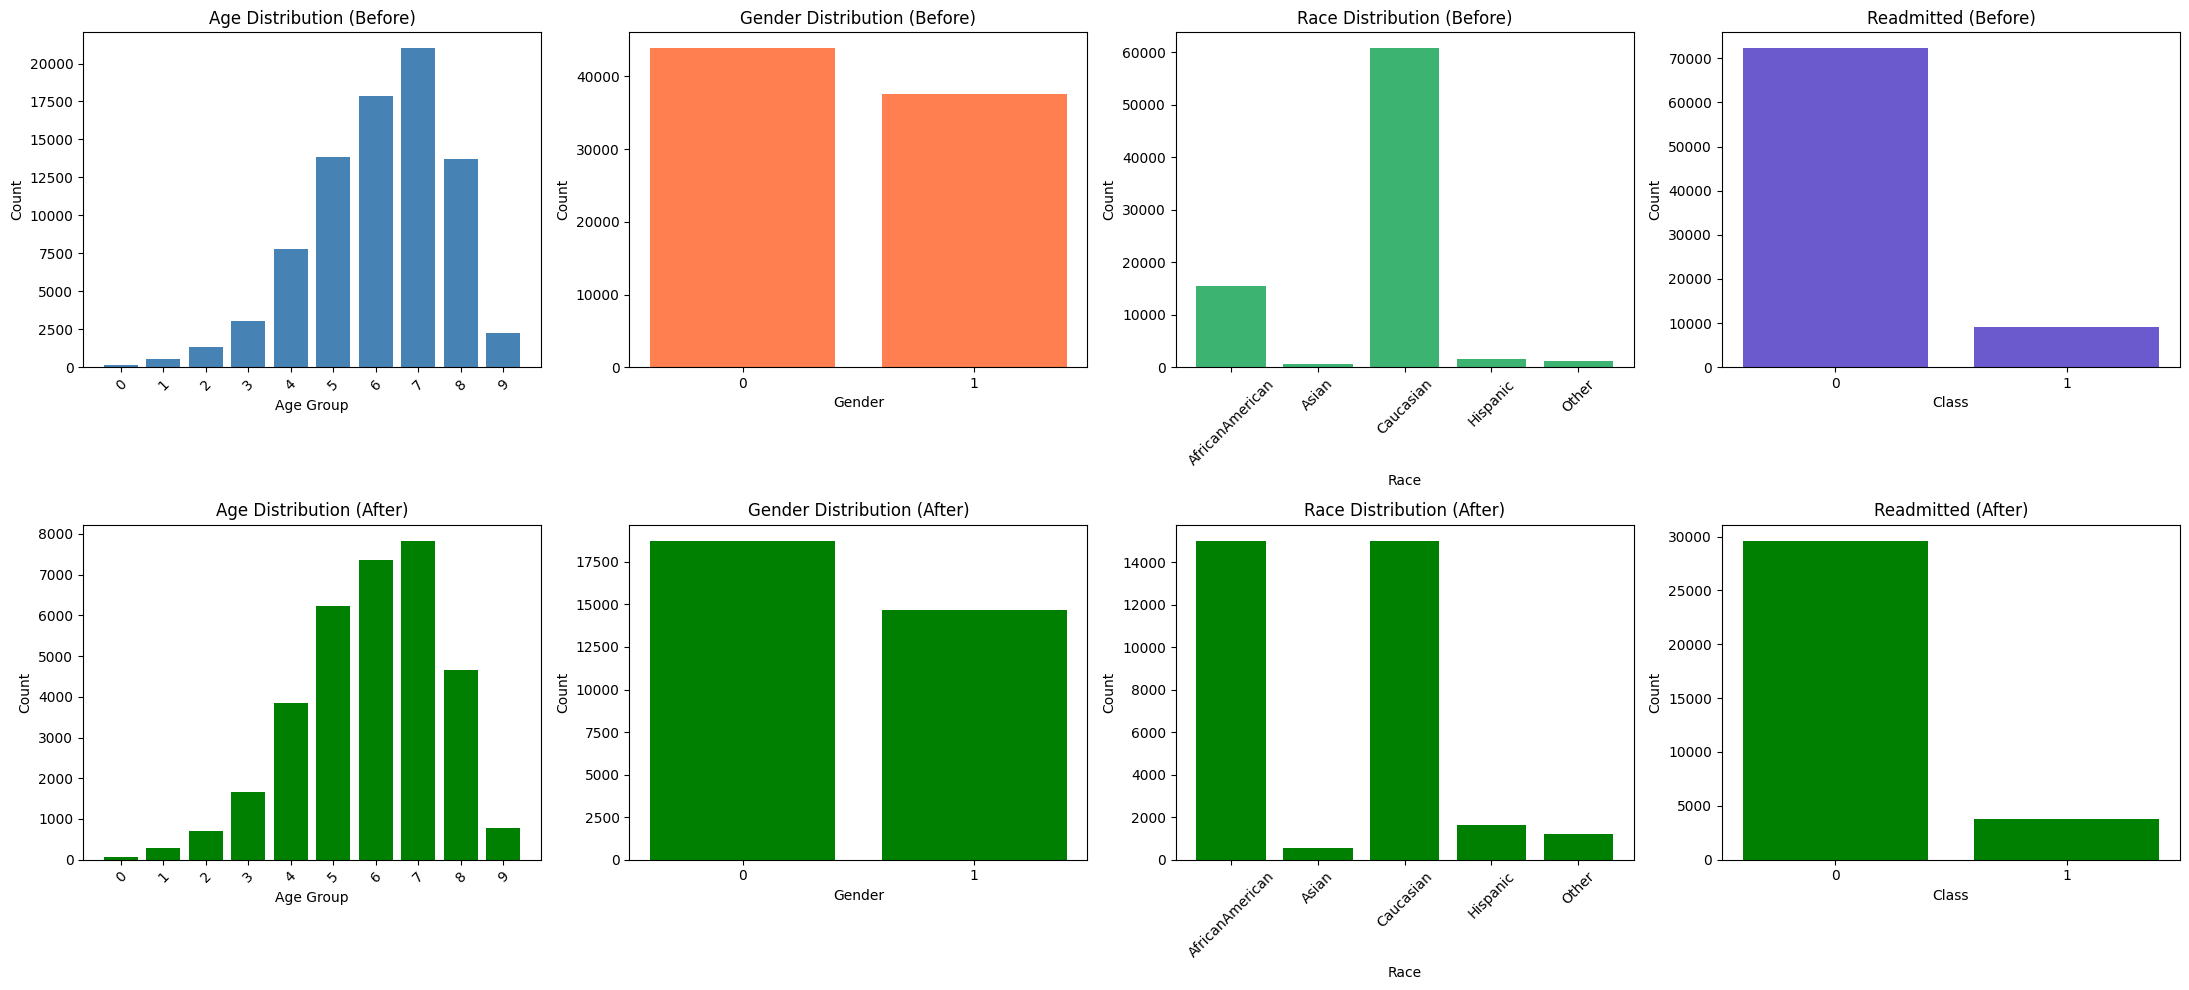

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# --- AGE ---
if 'age' in df.columns and 'age' in df_soft.columns:
    # Before
    age_counts_before = df['age'].value_counts().sort_index()
    axes[0, 0].bar(age_counts_before.index.astype(str), age_counts_before.values, color='steelblue')
    axes[0, 0].set_title('Age Distribution (Before)')
    axes[0, 0].set_xlabel('Age Group')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    # After
    age_counts_after = df_soft['age'].value_counts().sort_index()
    axes[1, 0].bar(age_counts_after.index.astype(str), age_counts_after.values, color='green')
    axes[1, 0].set_title('Age Distribution (After)')
    axes[1, 0].set_xlabel('Age Group')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

# --- GENDER ---
if 'gender' in df.columns and 'gender' in df_soft.columns:
    # Before
    gender_counts_before = df['gender'].value_counts().sort_index()
    axes[0, 1].bar(gender_counts_before.index.astype(str), gender_counts_before.values, color='coral')
    axes[0, 1].set_title('Gender Distribution (Before)')
    axes[0, 1].set_xlabel('Gender')
    axes[0, 1].set_ylabel('Count')
    # After
    gender_counts_after = df_soft['gender'].value_counts().sort_index()
    axes[1, 1].bar(gender_counts_after.index.astype(str), gender_counts_after.values, color='green')
    axes[1, 1].set_title('Gender Distribution (After)')
    axes[1, 1].set_xlabel('Gender')
    axes[1, 1].set_ylabel('Count')

# --- RACE ---
race_cols = [c for c in df.columns if c.startswith('race_')]
race_cols_soft = [c for c in df_soft.columns if c.startswith('race_')]
if race_cols and race_cols_soft:
    # Before
    race_counts_before = {col.replace('race_', ''): df[col].sum() for col in race_cols}
    axes[0, 2].bar(race_counts_before.keys(), race_counts_before.values(), color='mediumseagreen')
    axes[0, 2].set_title('Race Distribution (Before)')
    axes[0, 2].set_xlabel('Race')
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].tick_params(axis='x', rotation=45)
    # After
    race_counts_after = {col.replace('race_', ''): df_soft[col].sum() for col in race_cols_soft}
    axes[1, 2].bar(race_counts_after.keys(), race_counts_after.values(), color='green')
    axes[1, 2].set_title('Race Distribution (After)')
    axes[1, 2].set_xlabel('Race')
    axes[1, 2].set_ylabel('Count')
    axes[1, 2].tick_params(axis='x', rotation=45)

# --- TARGET VARIABLE ---
if 'readmitted' in df.columns and 'readmitted' in df_soft.columns:
    # Before
    target_counts_before = df['readmitted'].value_counts().sort_index()
    axes[0, 3].bar(target_counts_before.index.astype(str), target_counts_before.values, color='slateblue')
    axes[0, 3].set_title('Readmitted (Before)')
    axes[0, 3].set_xlabel('Class')
    axes[0, 3].set_ylabel('Count')
    # After
    target_counts_after = df_soft['readmitted'].value_counts().sort_index()
    axes[1, 3].bar(target_counts_after.index.astype(str), target_counts_after.values, color='green')
    axes[1, 3].set_title('Readmitted (After)')
    axes[1, 3].set_xlabel('Class')
    axes[1, 3].set_ylabel('Count')

plt.tight_layout()
plt.show()

### What Changed and Why This is 'Soft Balancing'

- **What changed:**
    - The largest race group(s) were capped at 15,000 samples, reducing extreme imbalance.
    - Smaller race groups were kept intact (not upsampled or removed).
    - The overall dataset size remains large and realistic.
    - The target variable (`readmitted`) and class proportions were not altered.
    - Gender and age distributions were not forced to be equal, only checked for distortion.

- **Why this is called "soft balancing":**
    - Instead of forcing all groups to have exactly the same size (strict balancing), we only reduce the dominance of the largest group(s).
    - This approach preserves as much data as possible while making the dataset more fair and less biased toward the majority group.
    - It is a practical compromise between fairness and data utility.

# Summary: What Changed and How Soft Balancing Was Done

**Soft demographic balancing** was applied to the dataset to reduce extreme imbalances in the age, race, and gender groups, while keeping the dataset size large and realistic. Here’s a summary of the process and its effects:

## What Was Done
- **No balancing was performed on the target variable (`readmitted`)**. The class distribution was left as-is to preserve the real-world outcome proportions.
- **No strict equalization**: We did not force all demographic groups to have exactly the same size. Instead, we reduced the dominance of the largest groups.
- **Soft balancing steps:**
    1. **Race:**
        - Identified all race groups (one-hot encoded columns).
        - Set a cap (e.g., 15,000 samples per race group).
        - For each group, if its size exceeded the cap, we randomly downsampled to the cap (using `random_state=42` for reproducibility). Smaller groups were kept intact.
    2. **Age:**
        - Set a cap (e.g., 8,000 samples per age group).
        - Downsampled only groups above the cap, keeping smaller groups intact.
    3. **Gender:**
        - Set a cap (e.g., 20,000 samples per gender group).
        - Downsampled only groups above the cap, keeping smaller groups intact.
- **At each step, the dataset was filtered further, so the final dataset is the intersection of all soft-balanced groups.**

## What Changed
- The largest race, age, and gender groups were reduced in size, making the dataset more balanced and less biased toward the majority groups.
- Smaller groups were preserved, so no information was lost from underrepresented groups.
- The overall dataset size decreased, but remains large and realistic for analysis and modeling.
- The target variable (`readmitted`) distribution was not artificially changed.

## Why This Is Called "Soft Balancing"
- **Soft balancing** means reducing extreme imbalances without enforcing strict equality.
- It is a practical compromise: we improve fairness and representation while preserving as much data as possible.
- This approach is especially useful in real-world datasets where strict balancing would require discarding too much data or upsampling rare groups unrealistically.

**In summary:**
- The dataset is now more fair and representative across demographic groups, but still realistic and useful for downstream analysis and modeling.

In [9]:
# Save the final soft-balanced dataset to CSV
output_path = 'balance_demographic_variable_training_dataset.csv'
df_soft.to_csv(output_path, index=False)
print(f'Soft-balanced demographic variable training dataset saved to {output_path}')
print(f'Final dataset shape: {df_soft.shape}')

Soft-balanced demographic variable training dataset saved to balance_demographic_variable_training_dataset.csv
Final dataset shape: (33390, 39)
